# [Title]

## Preparation

- https://github.com/Levine-l/CASA0006_project

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

## Research questions

[[ go back to the top ]](#Table-of-contents)

To what extent is Year 6 obesity prevalence across London MSOAs associated with area deprivation, socio-demographic composition, and neighbourhood green cover?

## Data

[[ go back to the top ]](#Table-of-contents)

#### **Data Introduction**

This project uses five datasets to examine how Year 6 obesity in London is associated with deprivation, selected socio-demographic characteristics, and neighbourhood green cover at MSOA level.

The dependent variable is taken from the [Prevalence of Childhood Obesity, Borough, Ward and MSOA](https://data.london.gov.uk/dataset/prevalence-of-childhood-obesity-borough-ward-and-msoa-23g07/) dataset from the London Datastore, which reports childhood weight outcomes for Reception and Year 6 pupils at multiple spatial scales, including MSOA.

Neighbourhood deprivation is measured using the [English Indices of Deprivation 2019](https://data.london.gov.uk/dataset/indices-of-deprivation-2l15g/
), which provide official deprivation measures for London. Socio-demographic characteristics are drawn from the [2021 Census Bulk Data Download](https://www.nomisweb.co.uk/sources/census_2021_bulk
), which includes census tables for MSOA such as ethnicity, housing tenure, education level, population density and household composition.

The environmental variable is based on the [Green Cover 2024](https://data.london.gov.uk/dataset/green-cover-2024-e56n0/) dataset, which provides estimates of green cover in London and related spatial layers. Finally, [London’s Statistical GIS Boundary Files](https://data.london.gov.uk/dataset/statistical-gis-boundary-files-for-london-20od9/) are used to support spatial referencing and mapping at MSOA level.

#### **Data Processing**

For Child obesity prevalence data, I use the worksheet from 2011-12 to 2013-14, and only retain records with MSOA level. The main variable was Year 6 obesity prevalence, but there are small number of MSOA level Year 6 obesity values ('year6_obese_pct') were missing, from the website it may  because the original NCMP data contained suppressed estimates for disclosure control, including low counts and other confidentiality-related suppressions. Since the dependent variable is unavailable rather than partially observed, these cases are retained during data assembly but would excluded from modelling through complete-case analysis.



Deprivation data are using the IMD 2019, IDACI and IDAOPI, and Population figures sheets from the London IMD workbook. Because these data were provided at LSOA 2011 level, they were aggregated to MSOA level using population weighted means. Overall IMD and domain scores were weighted by total population, while IDACI and IDAOPI were weighted by child and older population respectively, but ranks and deciles were not aggregated because they are ordinal measures of relative position and are not meaningfully averaged.


Neighbourhood green cover was processed from the 2024 green cover polygon tiles. The raw spatial data were provided as multiple tiled shapefiles but not aggregated statistical table. I use London MSOA boundaries and spatially intersected with green cover polygons, and calculate the total green cover area within each MSOA. Then converte cpver area into a percentage of total MSOA area to create the green cover exposure variable.

Socio-demographic covariates included population density, ethnic composition, housing tenure, unemployment and economic inactivity, qualifications, and household structure, which from ts003, ts006, ts021, ts054, ts066 and ts067. Original counts are converted into percentages to improve comparability across MSOAs.

Apart from aggregation, geography mismatch was identified between datasets, because obesity data aligned with MSOA 2011, while census and the first processed green cover data aligned with MSOA 2021. So I using London MSOA 2011 as the anchor geography, green cover was recalculated directly onto MSOA 2011 boundaries, while census variables were harmonised from MSOA 2021 back to MSOA 2011 using the official ONS best-fit lookup ([Best fit](https://www.data.gov.uk/dataset/9aa055b1-9b55-4d40-9be0-70bab8d55889/msoa-2011-to-msoa-2021-to-local-authority-district-2022-best-fit-lookup-for-ew-v21) for matching, [exact fit](https://www.data.gov.uk/dataset/da36cac8-51c4-4d68-a4a9-37ac47d2a4ba/msoa-2011-to-msoa-2021-to-local-authority-district-2022-exact-fit-lookup-for-ew-v2) for comparing different). The final harmonised analysis dataset therefore combined obesity, IMD, green cover, and census covariates on a common MSOA 2011 geography.

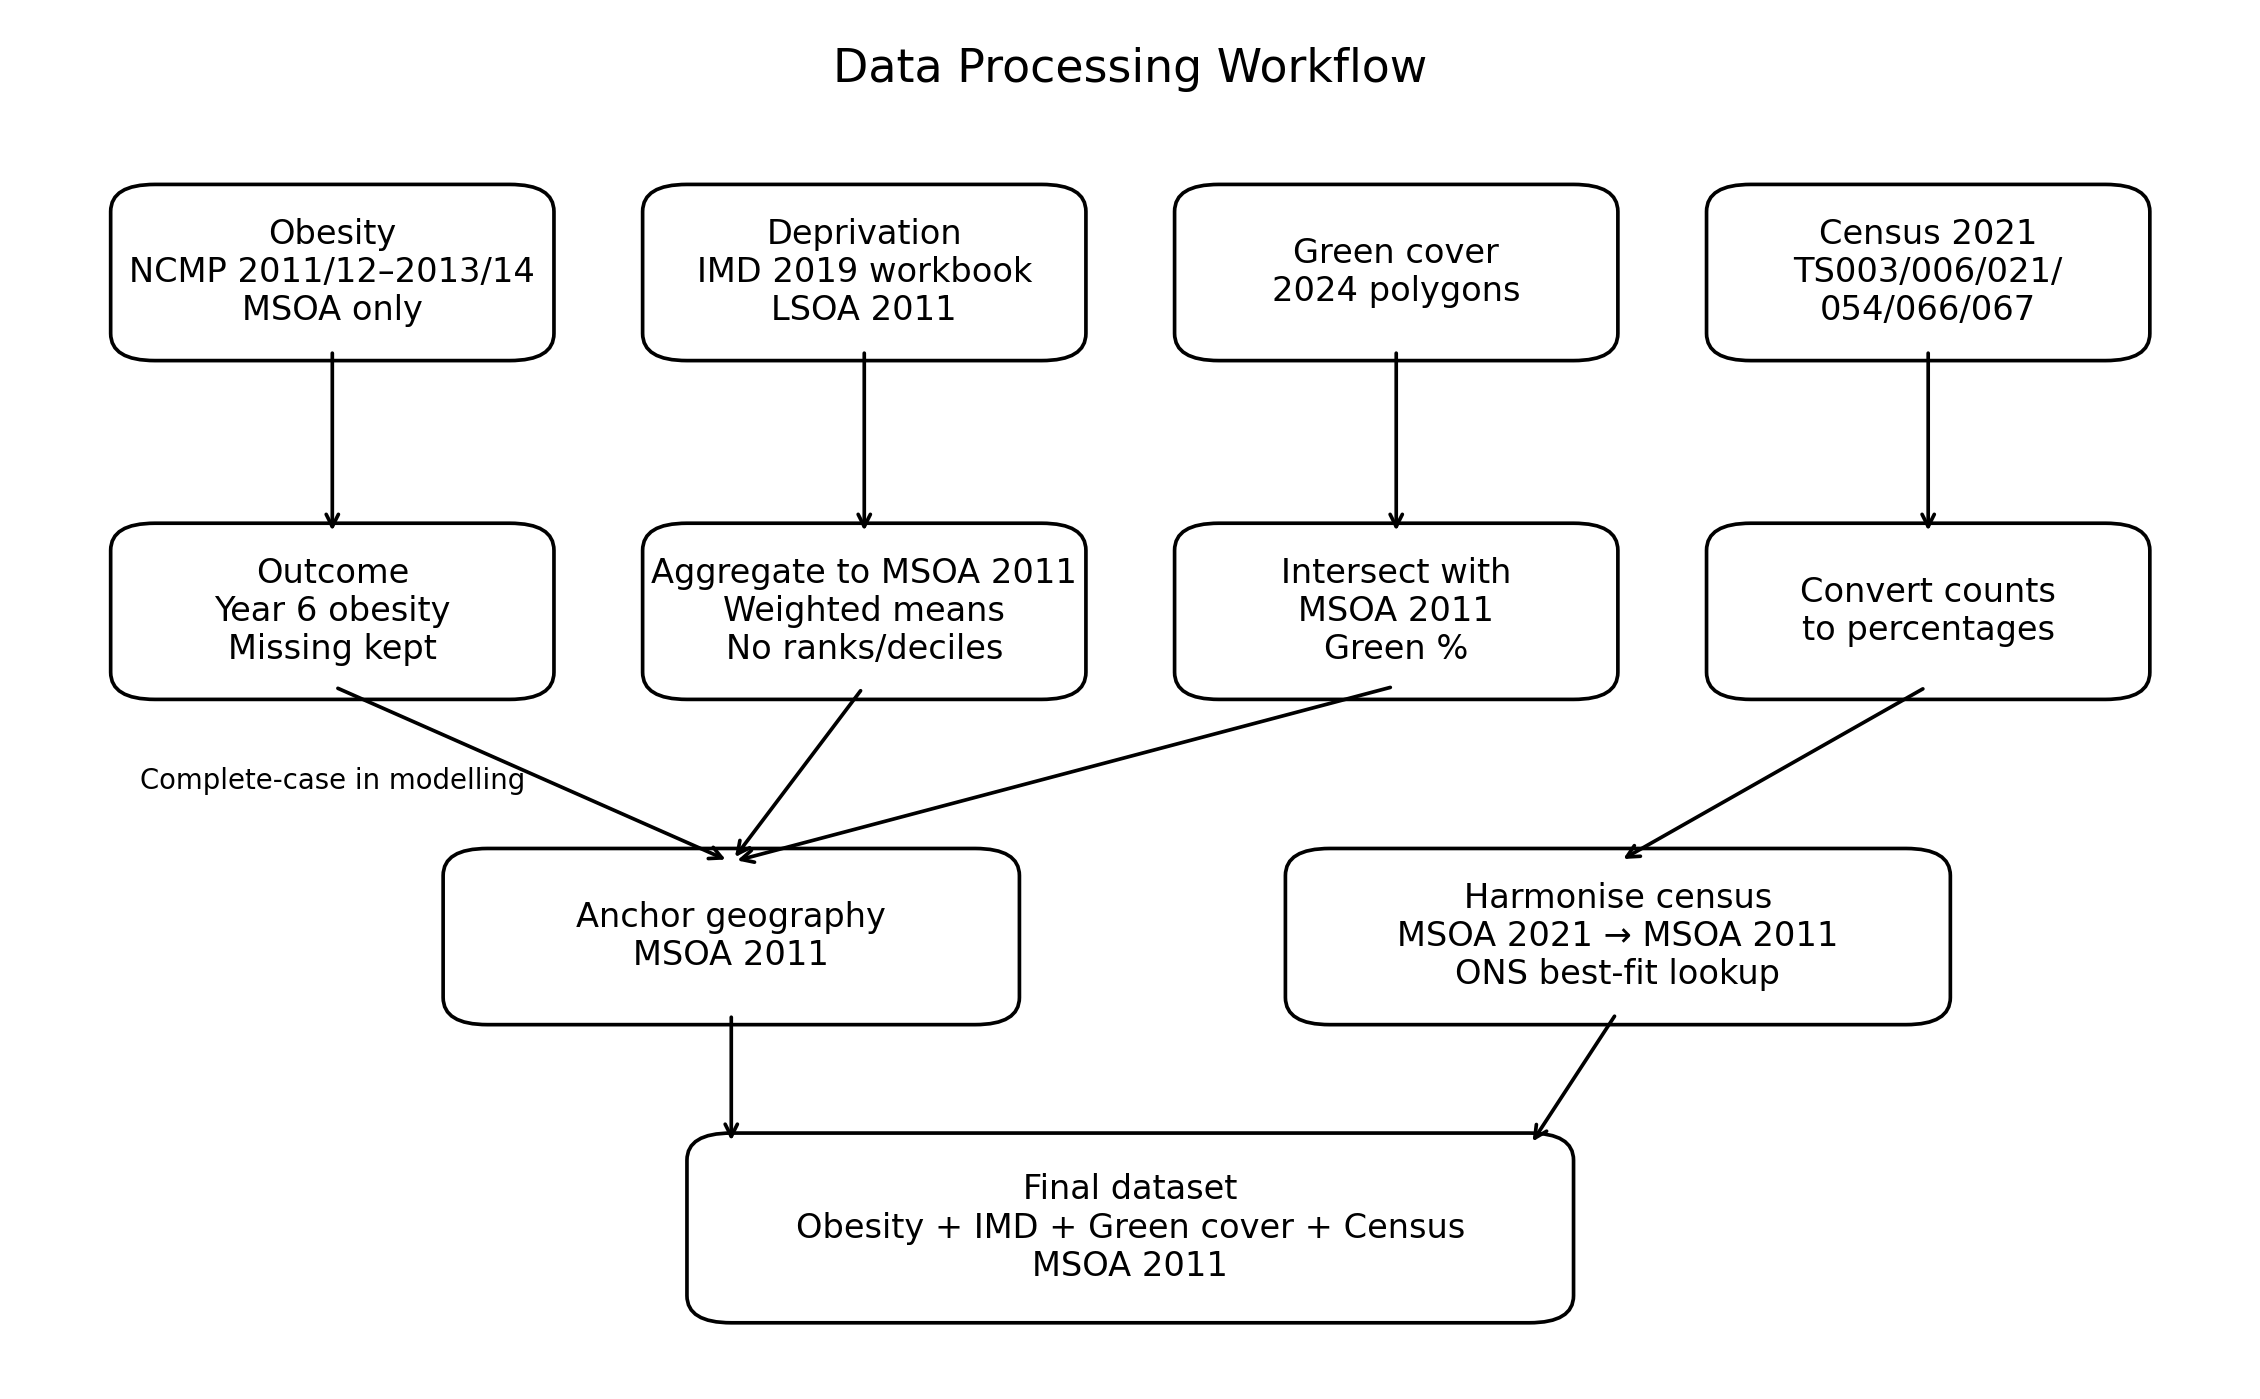

#### Variables used in the analysis

| Variable                                                                   | Type                     | Description                                                                                                      | Notes                                                                            |
| -------------------------------------------------------------------------- | ------------------------ | ---------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------- |
| Year 6 obesity prevalence (`year6_obese_pct`)                              | Numeric                  | Percentage of Year 6 children classified as obese at MSOA level. Used as the dependent variable in the analysis. | Main outcome variable.                                                           |
| Green cover percentage (`green_cover_pct`)                                 | Numeric                  | Percentage of land area classified as green cover within each MSOA. Used as the main exposure variable.          | Main exposure of interest.                                                       |
| Index of Multiple Deprivation score (`imd_score_weighted`)                 | Numeric                  | Population-weighted IMD 2019 score at MSOA level, representing overall area deprivation.                         | Main deprivation measure used in the core models.                                |
| Income Deprivation Affecting Children Index score (`idaci_score_weighted`) | Numeric                  | Child-population-weighted IDACI score at MSOA level, reflecting deprivation affecting children.                  | Used in sensitivity analysis rather than the main model due to overlap with IMD. |
| Population density (`population_density_per_sqkm`)                         | Numeric                  | Number of residents per square kilometre in each MSOA.                                                           | Included as a socio-demographic control.                                         |
| Black population percentage (`pct_black`)                                       | Numeric                  | Percentage of residents identifying as Black in each MSOA.                                                       | Socio-demographic covariate.                                                     |
| Asian population percentage (`pct_asian`)                                       | Numeric                  | Percentage of residents identifying as Asian in each MSOA.                                                       | Socio-demographic covariate.                                                     |
| Social rented housing percentage (`pct_social_rented`)                          | Numeric                  | Percentage of households living in socially rented accommodation in each MSOA.                                   | Socio-demographic covariate; may also reflect housing disadvantage.              |
| No qualifications percentage (`pct_no_qualifications`)                          | Numeric                  | Percentage of residents with no formal qualifications in each MSOA.                                              | Socio-demographic covariate.                                                     |
| Unemployment percentage (`pct_unemployed_16plus`)                               | Numeric                  | Percentage of residents aged 16+ who are unemployed in each MSOA.                                                | Socio-demographic covariate.                                                     |
| Lone-parent household percentage (`pct_lone_parent_households`)                 | Numeric                  | Percentage of households headed by a lone parent in each MSOA.                                                   | Socio-demographic covariate.                                                     |
| MSOA code (`MSOA_code`)                                                    | Categorical / Identifier | Unique code identifying each MSOA.                                                                               | Used for joining and reference only; not included as a predictor.                |
| MSOA name (`MSOA_name`)                                                    | Categorical / Identifier | Name of each MSOA.                                                                                               | Used for reporting and mapping only; not included as a predictor.                |
| Local authority district name (`LAD_name`)                                 | Categorical / Identifier | Name of the local authority district containing the MSOA.                                                        | Used for contextual reference only; not included as a predictor.                 |
| Exact fit match count (`exactfit_match_count`)                             | Numeric / Diagnostic     | Diagnostic field indicating the number of exact matches during spatial harmonisation or lookup.                  | Used for data quality checking only; not included in regression analysis.        |


## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

![image.png](attachment:image.png)

#### **Analytical strategy**

This study adopts a cross-sectional, MSOA-level analytical design to examine how Year 6 obesity prevalence in London is associated with neighbourhood green cover, area deprivation, and selected socio-demographic characteristics. The unit of analysis is the Middle Layer Super Output Area (MSOA). The dependent variable is Year 6 obesity prevalence (year6_obese_pct). The main explanatory variable is neighbourhood green cover percentage (green_cover_pct). Area deprivation is primarily represented by the population-weighted Index of Multiple Deprivation score (imd_score_weighted), while a child-focused deprivation measure, the Income Deprivation Affecting Children Index (idaci_score_weighted), is used in a sensitivity analysis rather than in the main model because of conceptual and statistical overlap with IMD.


The analysis is structured in three stages. First, descriptive and spatial exploratory analysis is used to examine the distribution of the outcome and key explanatory variables across London. Second, multivariable regression models are used to estimate the association between Year 6 obesity prevalence and the selected covariates. Third, sensitivity and diagnostic checks are used to assess whether the main findings are robust to alternative deprivation specifications and potential multicollinearity among predictors.

#### **Exploratory analysis**

The analysis begins with descriptive statistics for the outcome and explanatory variables, including measures of central tendency, dispersion, and missingness. Histograms and summary tables are used to inspect variable distributions. Spatial visualisation is then used to map Year 6 obesity prevalence, green cover, and deprivation across London MSOAs in order to identify broad spatial patterning and possible clustering.

Bivariate relationships are explored using scatterplots and a correlation matrix. This step is used to assess the direction and strength of pairwise relationships, especially between obesity prevalence and green cover, and between obesity prevalence and deprivation-related indicators. The exploratory analysis is not treated as causal evidence, but as a way to motivate the subsequent regression models and identify potential issues such as skewed distributions or high correlation among predictors.

#### **Regression modelling**
The main inferential approach is multivariable linear regression. This is appropriate because the research question is concerned with the extent to which Year 6 obesity prevalence is associated with environmental and socio-demographic characteristics, rather than with classification or purely predictive optimisation. Linear regression also provides coefficients that are relatively straightforward to interpret in substantive terms.

The modelling strategy is hierarchical. A baseline model includes the main deprivation variable only. A second model adds socio-demographic covariates, including population density, ethnic composition, housing tenure, educational disadvantage, unemployment, and lone-parent household prevalence. A third model adds green cover percentage in order to assess whether neighbourhood green cover remains associated with obesity prevalence after controlling for deprivation and socio-demographic composition.

This staged approach allows the analysis to distinguish between gross associations and associations that persist after adjustment for confounding area characteristics. The main focus is therefore on coefficient direction, relative magnitude, statistical significance, and changes in model fit across specifications.

#### **Variable handling and diagnostics**

Only substantively meaningful explanatory variables are included in the regression models. Identifier fields such as MSOA_code, MSOA_name, and LAD_name are used for joining, mapping, and reporting only, and are not treated as predictors. Likewise, harmonisation or matching diagnostics such as exactfit_match_count are used for data quality checking rather than as explanatory variables.

Because several area-level variables may capture related dimensions of deprivation and disadvantage, multicollinearity is assessed before fitting the final regression models. This is initially examined through the correlation matrix and then checked more formally using variance inflation factors. Where variables are found to be highly overlapping, model specifications are simplified to improve interpretability and reduce instability in coefficient estimates.

Cases with missing values on the dependent variable or selected modelling variables are excluded through complete-case analysis. This approach is appropriate here because the proportion of missing values is relatively small and the objective is to estimate consistent associations across a harmonised analytical dataset.

#### **Sensitivity analysis**

A sensitivity analysis is used to test whether the main findings depend on how deprivation is measured. In the core models, area deprivation is represented by imd_score_weighted. In an alternative specification, this is replaced by idaci_score_weighted, which captures child-related income deprivation more directly. This comparison is intended to assess whether the observed association between green cover and obesity prevalence is robust when a more child-specific deprivation indicator is used.

An optional comparison model using a non-linear machine learning approach, such as random forest regression, may also be estimated as a secondary robustness check. This model is not treated as the main inferential framework, but as a way to examine whether variable importance rankings are broadly consistent with the linear regression results.



#### **Limitations of the approach**
The methodology is designed to identify area-level associations rather than causal effects. The study uses cross-sectional data drawn from multiple sources that are not perfectly contemporaneous, so the results should be interpreted as approximate neighbourhood-level relationships rather than strict point-in-time effects. In addition, the analysis is conducted at MSOA level, which means that findings apply to spatial aggregates and should not be interpreted as evidence about individual children or households.

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

## Conclusion

[[ go back to the top ]](#Table-of-contents)

## References

[[ go back to the top ]](#Table-of-contents)